# CICIDS2017 — Step 1: Load, Clean and Baseline Models



### 0. Install libraries (run once)
If any import fails, remove the `#` and run this cell.

In [16]:
# !pip install numpy pandas scikit-learn matplotlib seaborn pyarrow

### 1. Load and merge the 8 CSV files
Notes baked in for CICIDS2017:
- `encoding='latin1'` avoids a crash on the web-attack file, which contains a non-standard dash character.
- `.str.strip()` removes the leading spaces in the column names (a very common CICIDS2017 bug).

In [17]:
import glob, os, time
import numpy as np
import pandas as pd

# >>> CHANGE THIS to your unzipped folder path <<<
DATA_DIR = "../data"

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
print(f"Found {len(csv_files)} CSV files in '{DATA_DIR}'")
assert len(csv_files) > 0, "No CSV files found. Check the DATA_DIR path."

frames = []
for f in csv_files:
    df = pd.read_csv(f, encoding="latin1", low_memory=False)
    df.columns = df.columns.str.strip()   # remove leading/trailing spaces from column names
    print(f"  {os.path.basename(f):55s} {df.shape}")
    frames.append(df)

data = pd.concat(frames, ignore_index=True)


print("\nMerged dataset shape:", data.shape)

Found 8 CSV files in '../data'
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        (225745, 79)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    (286467, 79)
  Friday-WorkingHours-Morning.pcap_ISCX.csv               (191033, 79)
  Monday-WorkingHours.pcap_ISCX.csv                       (529918, 79)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (288602, 79)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (170366, 79)
  Tuesday-WorkingHours.pcap_ISCX.csv                      (445909, 79)
  Wednesday-workingHours.pcap_ISCX.csv                    (692703, 79)

Merged dataset shape: (2830743, 79)


In [18]:
# Inspect the raw label values before cleaning
print(data['Label'].value_counts())
print("\nNumber of unique labels:", data['Label'].nunique())

Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64

Number of unique labels: 15


In [19]:
import re

def clean_label(s):
    s = str(s).strip()
    # Replace ONLY the mangled non-ASCII dash; leave real hyphens alone
    s = re.sub(r'[^\x00-\x7F]+', '-', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

data['Label'] = data['Label'].apply(clean_label)

print(data['Label'].value_counts())
print("\nNumber of unique labels:", data['Label'].nunique())

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Number of unique labels: 15


### 2. Clean the data
Remove infinite values, missing values, and duplicate rows. This matches the cleaning step described in your methodology.

In [20]:
# The label column is usually named 'Label' after stripping spaces
label_col = "Label"
assert label_col in data.columns, f"Columns are: {list(data.columns)[-5:]}"

# Replace infinities with NaN (Flow Bytes/s and Flow Packets/s contain Inf)
data.replace([np.inf, -np.inf], np.nan, inplace=True)

before = len(data)
data.dropna(inplace=True)
print("Rows removed (NaN / Inf):", before - len(data))

before = len(data)
data.drop_duplicates(inplace=True)
print("Rows removed (duplicates):", before - len(data))

data.reset_index(drop=True, inplace=True)
print("Clean dataset shape:", data.shape)

Rows removed (NaN / Inf): 2867
Rows removed (duplicates): 307078
Clean dataset shape: (2520798, 79)


### 3. Look at the class distribution
This is the imbalance your project is built around. Notice how tiny the rare attack classes are compared with BENIGN.

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Number of classes: 15


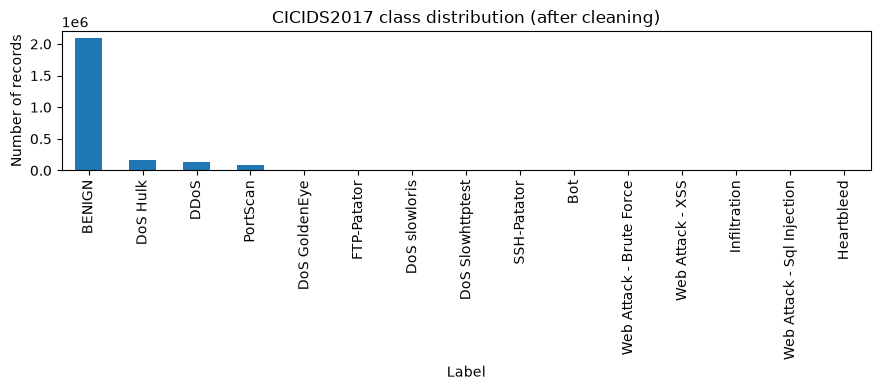

In [21]:
data[label_col] = data[label_col].astype(str).str.strip()
dist = data[label_col].value_counts()
print(dist)
print("\nNumber of classes:", data[label_col].nunique())

# quick bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
dist.plot(kind="bar")
plt.title("CICIDS2017 class distribution (after cleaning)")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

### 4. Build features and a binary target
For this first baseline we use **binary** classification: BENIGN (0) vs any attack (1). It is fast and proves the pipeline works. The full multiclass version, which lets you report recall per attack type, comes in the next stage.

In [22]:
# Binary target: 0 = benign, 1 = attack
y = (data[label_col] != "BENIGN").astype(int)

# Features = everything except the label
X = data.drop(columns=[label_col])

# Force everything numeric and drop any rows that become invalid
X = X.apply(pd.to_numeric, errors="coerce")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

print("Feature matrix:", X.shape)
print("Target balance:\n", y.value_counts(normalize=True).round(4))

Feature matrix: (2520798, 78)
Target balance:
 Label
0    0.8311
1    0.1689
Name: proportion, dtype: float64


### 5. Stratified 70:30 train / test split
Stratified keeps the same class proportions in both parts. `random_state=42` makes it reproducible.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1764558, 78)  Test: (756240, 78)


### 6. Baseline models

**Important:** the scaler is fitted on the training data **only**, then applied to the test data. This prevents information leaking from test into train. Logistic Regression needs scaling because it is sensitive to feature size. The Decision Tree does not need scaling, so it is trained on the raw features.

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# scale for Logistic Regression 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

#  Logistic Regression 
t = time.time()
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
lr_train_time = time.time() - t

t = time.time()
lr_pred = lr.predict(X_test_s)
lr_infer_time = time.time() - t

print("=== LOGISTIC REGRESSION ===")
print(f"Train time: {lr_train_time:.2f}s   Inference time: {lr_infer_time:.2f}s")
print(classification_report(y_test, lr_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, lr_pred))

=== LOGISTIC REGRESSION ===
Train time: 226.95s   Inference time: 0.89s
              precision    recall  f1-score   support

           0     0.9718    0.9766    0.9742    628518
           1     0.8818    0.8608    0.8712    127722

    accuracy                         0.9570    756240
   macro avg     0.9268    0.9187    0.9227    756240
weighted avg     0.9566    0.9570    0.9568    756240

Confusion matrix:
 [[613785  14733]
 [ 17782 109940]]


In [25]:
#
t = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_train_time = time.time() - t

t = time.time()
dt_pred = dt.predict(X_test)
dt_infer_time = time.time() - t

print("=== DECISION TREE ===")
print(f"Train time: {dt_train_time:.2f}s   Inference time: {dt_infer_time:.2f}s")
print(classification_report(y_test, dt_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, dt_pred))

=== DECISION TREE ===
Train time: 402.26s   Inference time: 2.09s
              precision    recall  f1-score   support

           0     0.9990    0.9992    0.9991    628518
           1     0.9959    0.9950    0.9954    127722

    accuracy                         0.9985    756240
   macro avg     0.9974    0.9971    0.9973    756240
weighted avg     0.9985    0.9985    0.9985    756240

Confusion matrix:
 [[627993    525]
 [   639 127083]]


### 7. (Optional) Save the cleaned data
Saving now means you do not have to re-load and re-clean the 8 files every time. Parquet is fast and small. If `pyarrow` is not installed, use the CSV line instead.

In [26]:
# data.to_parquet("cicids2017_clean.parquet")   # fast, needs pyarrow
# data.to_csv("cicids2017_clean.csv", index=False)  # bigger, always works
print("Uncomment a line above to save.")

Uncomment a line above to save.


In [27]:
data.to_pickle('../data/merged_clean.pkl')
print("Saved:", data.shape)

Saved: (2520798, 79)


---
## What to do after running this

- If both models run and print a classification report, your pipeline works. That is a real milestone you can write into **Section 4.1 (Current status)** of your interim report.
- **Expect very high accuracy** (often 99%+). Do not celebrate it. Look at the **recall** row for the attack class and the confusion matrix instead. High accuracy on CICIDS2017 is easy and can hide poor detection of rare attacks. This is exactly the point Engelen et al. (2021) make and the reason your evaluation focuses on recall, F1 and false alarm rate.
- **Next stage (do not do yet):** switch to multiclass, add filter-based feature selection, add SMOTE on the training data only, then tune with Grid Search and 10-fold cross validation. Tell me when the baseline runs and I will write that stage for you.

**If Logistic Regression is very slow or warns about convergence:** that is normal on 2 million+ rows. It still works. You can raise `max_iter` or, for a quick test, train on a stratified sample first.